## building a simple workflow or graph using langgraph

 state -  “state” feature serves as a memory bank that records and tracks all the valuable information processed by the ai system 

In [2]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info : str

nodes - nodes are just python functions
because the state is a TypeDict with schema as defined above each node can access the key,graph_state with state['graphstate']
each nodes return a new value 

In [3]:
def start_play(state:State):
    print("start_play node has been called!")
    return {"graph_info": state["graph_info"] + " I am planning to play"}

def cricket_play(state:State):
    print("cricket_play node has been called!")
    return {"graph_info": state["graph_info"] + " I am playing cricket"}

def football_play(state:State):
    print("football_play node has been called!")
    return {"graph_info": state["graph_info"] + " I am playing football"}

def end_play(state:State):
    print("end_play node has been called!")
    return {"graph_info": state["graph_info"] + " I have finished playing"}

In [13]:
import random
from typing import Literal

def random_play(state:State) -> Literal['cricket_play', 'football_play']:
    graph_info = state["graph_info"]
    print("random_play node has been called!")
    if random.random() < 0.5:
        print("I have decided to play cricket")
        return 'cricket_play'
    else:
        print("I have decided to play football")
        return 'football_play'
        

### graph construction

* now,we will build a graph from our components
* we initialize a stateGraph with  the state class we defined above
* we add our nodes and edges
* we use the start node a special node taht sends use input to the graph to indicate where to start our graph
* the end node , special node that represents terminal node
* finally, we compile our graph to perform a few basic checks on the graph structure

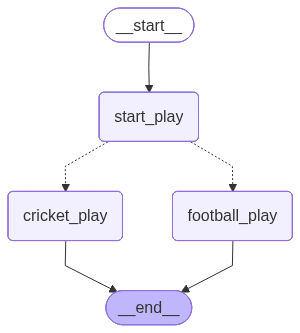

In [15]:
from IPython.display import Image, display
from langgraph.graph import StateGraph,START, END
from langgraph.graph import START

# build a graph 

graph = StateGraph(State)

#adding the nodes to the graph

graph.add_node("start_play", start_play)
graph.add_node("cricket_play", cricket_play)
graph.add_node("football_play", football_play)

#schedule teh flow of the graph 

graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)   
graph.add_edge("cricket_play", END)
graph.add_edge("football_play", END)


#compile the graph
graph_builder = graph.compile()

#view the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [19]:
## graph invocation
graph_builder.invoke({"graph_info": "I am a person who wants to play. "})


start_play node has been called!
random_play node has been called!
I have decided to play football
football_play node has been called!


{'graph_info': 'I am a person who wants to play.  I am planning to play I am playing football'}